In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
import re

import yfinance as yf
import seaborn as sns
import copy
import torch.nn as nn
import torch.optim as optim
import torch
import random

import os
import re

[*********************100%***********************]  30 of 30 completed


Ticker,Date,SHW,GS,HD,IBM,NKE,HON,JNJ,DIS,VZ,...,V,AMGN,MCD,TRV,JPM,CVX,MRK,UNH,CSCO,PG
0,2009-01-02,19.996668,86.760002,24.129999,83.527725,13.265,31.144005,60.650002,23.920000,32.488476,...,13.3600,58.990002,63.750000,45.200001,31.350000,76.519997,29.580153,27.590000,16.959999,62.799999
1,2009-01-05,19.946667,88.779999,24.709999,83.001915,13.360,30.982264,60.049999,23.500000,30.462635,...,13.4550,59.650002,63.560001,44.529999,29.250000,76.660004,29.131680,27.139999,17.110001,62.349998
2,2009-01-06,20.136667,88.709999,25.260000,85.305923,13.090,32.384014,59.689999,24.309999,29.974932,...,14.4025,58.340000,62.139999,43.169998,29.879999,77.349998,28.597328,26.500000,17.790001,62.169998


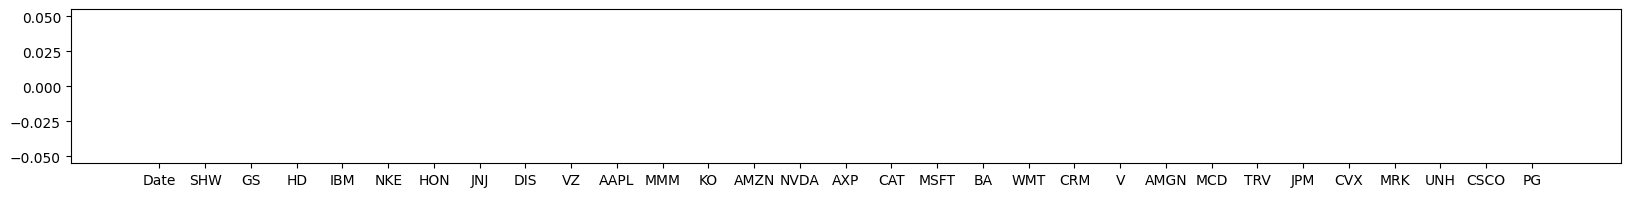

In [2]:
raw_tickers = [
 "NYSE:MMM", "NASDAQ:AMZN", "NYSE:AXP", "NASDAQ:AMGN",
 "NASDAQ:AAPL", "NYSE:BA", "NYSE:CAT", "NYSE:CVX",
 "NASDAQ:CSCO", "NYSE:KO", "NYSE:DIS", "NYSE:GS",
 "NYSE:HD", "NASDAQ:HON", "NYSE:IBM", "NYSE:JNJ",
 "NYSE:JPM", "NYSE:MCD", "NYSE:MRK", "NASDAQ:MSFT",
 "NYSE:NKE", "NASDAQ:NVDA", "NYSE:PG", "NYSE:CRM",
 "NYSE:SHW", "NYSE:TRV", "NYSE:UNH", "NYSE:VZ",
 "NYSE:V", "NYSE:WMT"
]

tickers = [t.split(":")[1] for t in raw_tickers]


rawdata = yf.download(
    tickers,
    start="2009-01-01",
    end="2018-09-30",
    group_by="ticker",
    auto_adjust=False
)

raw = rawdata.reset_index()
df = (raw.set_index(('Date','')).xs('Close', axis=1, level=1).reset_index())
df = df.rename(columns={('Date',''): 'Date'})
df['Date'] = pd.to_datetime(df['Date'])  # df is the close

# check missing values
checknull = df.isnull().sum()
plt.figure(figsize=(20, 2))
plt.bar(checknull.index, checknull.values)

# Split data into train, validation, and test sets
train_df = df[df['Date'] < '2015-01-01']
val_df = df[(df['Date'] >= '2015-01-01') & (df['Date'] < '2016-01-01')]
test_df = df[df['Date'] >= '2016-01-01']

train_df.head(3)

In [3]:
class Env:
    def __init__(self, train_df, initial_balance):
        self.initial_balance = initial_balance
        self.portfolio_value = self.initial_balance
        self.price = train_df.iloc[:, 1:].values.astype(np.float32) # stock price data, shape (T, num_stocks)
        self.train_df = train_df
        self.T = len(train_df) - 1 # total time steps


    def reset(self):
        self.t = 0 #initial time step t = 0
        self.holdings = np.zeros(self.price.shape[1], dtype=np.float32) # initial stock holdings, shape (num_stocks,) is 0
        self.balance = np.float32(self.initial_balance) # initial cash balance
        self.portfolio_value = np.float32(self.initial_balance) # initial portfolio value is the same as initial balance
        return self._get_state() # return initial state


    # s_t = [p_t, holdings, balance]
    def _get_state(self):
        p_t = self.price[self.t]
        state = np.concatenate([
            p_t,     #p_t current stock price
            self.holdings,        # h_t current stock holdings
            np.array([self.balance], dtype=np.float32)  # b_t current cash balance
        ])

        return state.astype(np.float32)


    def step(self, action):
        p_t = self.price[self.t] # current stock price at time t

        # action is continuous number of shares traded
        # positive means buy, negative means sell, 0 means hold
        action = np.asarray(action, dtype=np.float32)

        # sell can't exceed current holdings
        action = np.maximum(action, -self.holdings)

        old_port_value = np.dot(p_t, self.holdings) + self.balance

        # separate sell actions and buy actions
        sell_action = np.minimum(action, 0.0)
        buy_action = np.maximum(action, 0.0)

        # execute all sells first
        sell_gain = np.dot(-sell_action, p_t)
        self.holdings += sell_action
        self.balance += sell_gain

        # compute total desired buy cost
        buy_cost = np.dot(buy_action, p_t)

        # if cash is not enough, scale buy orders proportionally
        if buy_cost > self.balance and buy_cost > 0:
            buy_action = buy_action * (self.balance / buy_cost)
            buy_cost = np.dot(buy_action, p_t)

        # execute buys
        self.holdings += buy_action
        self.balance -= buy_cost

        # numerical cleanup
        self.holdings = np.maximum(self.holdings, 0.0).astype(np.float32)
        self.balance = np.float32(max(self.balance, 0.0))

        # move to next time t + 1
        self.t += 1

        p_next = self.price[self.t] # update price for next day
        new_port_value = np.dot(p_next, self.holdings) + self.balance
        self.portfolio_value = np.float32(new_port_value)

        reward = self.portfolio_value - old_port_value

        done = self.t >= self.T  # end episode when we reach the end of the data

        return self._get_state(), reward, done

In [4]:
# actor-critic methods, learn from both action and policy

# actor network (3 layers) input state, output action, it is randomly started
# actor 根据当前 state 决定 action
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(), #ReLU(x)=max(0,x)
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),

        )

    def forward(self, state):
        action = self.net(state) # input state, after doing the network above, output action
        return action

# Critic network (3 layers)  input state & action, output q value , it is randomly started
# critic 评估“在这个 state 下采取这个 action 好不好”
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, state, action):
        q_value = self.net(torch.cat([state, action], dim=1))
        return q_value

In [5]:
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.capacity = capacity
        self.buffer = []  # pool
        self.position = 0  # position in the pool --> i

    # Save data (state, action, next_state, reward) into the pool
    def add(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity  # overwrite old data when capacity is reached  (maybe not necessary since we want to save all data)

    #  Sample size N (batch_size) we want to batch
    def sample(self, batch_size):
        sample_buffer = random.sample(self.buffer, batch_size)
        return sample_buffer


    def __len__(self):
        return len(self.buffer)

In [6]:
def train_model(train_df, initial_value, sigma, N, gamma, tau, M):
    '''
    train_df: training data
    initial_value: initial portfolio value (initial balance)
    sigma: Gaussian noise parameter
    N: batch size
    gamma: discount factor
    tau: target network update rate
    M: number of episodes
    '''
    state_dim = (train_df.shape[1] -1 ) * 2 + 1 # state [p,h,b]: price vector + holding vector + balance so 61
    action_dim = (train_df.shape[1] -1 ) # 30

    actor = Actor(state_dim, action_dim)
    critic = Critic(state_dim, action_dim)
    actor_target = copy.deepcopy(actor)
    critic_target = copy.deepcopy(critic)

    # Adaptive Moment Estimation (Adam) optimizer
    critic_optimizer = optim.Adam(critic.parameters(), lr=1e-3)
    actor_optimizer = optim.Adam(actor.parameters(), lr=1e-4)

    env = Env(train_df, initial_value) # create environment with training data and initial balance
    R = ReplayBuffer() # inititialize replay buffer


    for episode in range(M):
        s_t = env.reset()
        done = False


        # initial portfolio value for this episode
        portfolio_values = [env.portfolio_value]

        while not done:
            s_t_tensor = torch.FloatTensor(s_t).unsqueeze(0) # convert state to tensor and add batch dimension

            with torch.no_grad():
                a_t = actor(s_t_tensor) # input current state, output action for current state  mu(s_t | theta^mu)

            noise = np.random.normal(0, sigma, size=action_dim) # create noise
            a_t = (a_t + noise).cpu().numpy().flatten()  # action with noise a_t =  mu(s_t | theta^mu)  + noise (N_t)  #.cpu() Network is working on GPU, covert to cpu then 将 PyTorch tensor 转回 numpy array, flatten() 将 action 从 shape (1, action_dim) 转成 shape (action_dim,)
            s_next, r, done = env.step(a_t) # input action a_t, changed the env, output next state s_next, reward r

            # record new portfolio value after action
            portfolio_values.append(env.portfolio_value) # record portfolio value after taking action


            R.add(s_t, a_t, r, s_next, done) # save (state, action, reward, next_state, done) into replay buffer
            s_t = s_next # update state to next state for next step

            if len(R) >= N:
                batch = R.sample(N) # randomly sample a batch of size N from replay buffer
                s, a, r, s_next_batch, done_batch = zip(*batch) # unzip the batch into separate lists for states, actions, rewards, next states, and done flags

                s = torch.FloatTensor(np.array(s)) # convert list of states to tensor, shape (N, state_dim)
                a = torch.FloatTensor(np.array(a)) # convert list of actions to tensor, shape (N, action_dim)
                r = torch.FloatTensor(np.array(r)).unsqueeze(1) # convert list of rewards to tensor and add dimension, shape (N, 1)
                s_next_batch = torch.FloatTensor(np.array(s_next_batch)) # convert list of next states to tensor, shape (N, state_dim)
                done_batch = torch.FloatTensor(np.array(done_batch)).unsqueeze(1) # convert list of done flags to tensor and add dimension, shape (N, 1)

                with torch.no_grad():
                    next_actions = actor_target(s_next_batch) # input next states, output next actions from target actor network  a_next = mu'(s_next | theta^mu')
                    target_Q = critic_target(s_next_batch, next_actions) #Q', input next states and next actions, output target Q value from target critic network Q'(s_next, a_next | theta^Q')

                    # Bellman target
                    # r is the immediate reward, gamma is the discount factor, done_batch indicates if the episode ended at that step (1 if done, 0 if not), target_Q is the estimated Q value for the next state and action.
                    y = r + gamma * (1 - done_batch) * target_Q   #Q'


                # critic update
                Q_pred = critic(s, a) # get current Q value
                critic_loss = nn.MSELoss()(Q_pred, y)

                critic_optimizer.zero_grad() # clear previous gradients before backward pass
                critic_loss.backward() # tells where the critic network parameters should be updated to minimize the critic loss
                critic_optimizer.step() # update critic network parameters based on the gradients calculated above


                # actor update
                actor_loss = -critic(s, actor(s)).mean() # maximize Q value by updating actor, equivalent to minimize -Q value
                actor_optimizer.zero_grad() # clear previous gradients before backward pass
                actor_loss.backward()  # tells where the actor network parameters should be updated to minimize the actor loss (or maximize Q value)
                actor_optimizer.step() # update actor network parameters based on the gradients calculated above


                # target update
                for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                    target_param.data.copy_(
                        tau * param.data + (1 - tau) * target_param.data #
                    )

                for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                    target_param.data.copy_(
                        tau * param.data + (1 - tau) * target_param.data
                    )


    return actor, portfolio_values

In [7]:
# stats
def drawdowns(portfolio_values):
    portfolio_values = np.asarray(portfolio_values, dtype=float)
    running_peak = np.maximum.accumulate(portfolio_values)
    dd = (running_peak - portfolio_values) / running_peak
    return dd

def statistics_results(portfolio_values, initial_value, rf):

    final_port_value = portfolio_values[-1]

    # daily returns   r = Vt- Vt-1 / Vt-1
    daily_return = np.diff(portfolio_values) / portfolio_values[:-1]

    # annualized return
    ann_return = np.mean(daily_return)* 252

    # annualized std
    annual_std = np.std(daily_return) * np.sqrt(252)

    # sharpe ratio
    sr_ratio = (ann_return - rf) / annual_std

    # DRAWDOWN
    dd = drawdowns(portfolio_values)

    # AVG drawdown and max drawdown
    avg_drawdown = np.mean(dd)
    max_drawdown = np.max(dd)


    return initial_value, final_port_value, ann_return, annual_std, sr_ratio, max_drawdown, avg_drawdown

In [8]:
def run_testing(env, actor):
    s_t = env.reset()
    portfolio_values = [env.portfolio_value]
    done = False


    while not done:
        s_t_tensor = torch.FloatTensor(s_t).unsqueeze(0)

        with torch.no_grad():
            a_t = actor(s_t_tensor).cpu().numpy().flatten()

        # no noise in testing
        s_t, r, done = env.step(a_t)

        portfolio_values.append(env.portfolio_value)


    return portfolio_values

In [10]:
# train on the optimal parameters
initial_value = 10000
M = 10  # number of episodes
sigma = 0.05  # for Gaussian noise
gamma = 0.95  # discount factor
tau = 0.005   # learning rate
N =  64 # batch size

# including th validation period into the training data set
train_df = df[df['Date'] < '2016-01-01']

# training
actor_train, portfolio_values_train= train_model(train_df, initial_value, sigma, N, gamma, tau, M)
ddpg_stats_train = statistics_results(portfolio_values_train, initial_value, rf=0.015)
print(ddpg_stats_train)

# testing
test_env = Env(test_df, initial_value)
test_portfolio = run_testing(test_env,actor_train)
ddpg_stats_test = statistics_results(test_portfolio, initial_value, rf=0.015)
print(ddpg_stats_test)

/tmp/ipykernel_11739/3282878955.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  a_t = (a_t + noise).cpu().numpy().flatten()  # action with noise a_t =  mu(s_t | theta^mu)  + noise (N_t)  #.cpu() Network is working on GPU, covert to cpu then 将 PyTorch tensor 转回 numpy array, flatten() 将 action 从 shape (1, action_dim) 转成 shape (action_dim,)


(10000, np.float32(23788.326), np.float32(0.13836277), np.float64(0.1692316146184164), np.float64(0.7289581500141499), np.float64(0.256823876953125), np.float64(0.03224085872910766))
(10000, np.float32(15266.159), np.float32(0.16138723), np.float64(0.11665485161466344), np.float64(1.2548748063537594), np.float64(0.11561836288740507), np.float64(0.025271233169244338))


In [11]:
import cvxpy as cp

# download data
data = yf.download(
    tickers=tickers,
    start="2009-01-01",
    end="2018-09-30",
    auto_adjust=True
)

prices = data["Close"]
returns = prices.pct_change().dropna()

train_returns = returns.loc["2009-01-01":"2015-12-31"]
test_returns  = returns.loc["2016-01-01":]

train_data = train_returns.values
num_samples, num_assets = train_data.shape

# covariance matrix
Sigma = np.cov(train_data.T)

# variable
w = cp.Variable(num_assets)

# objective
objective = cp.Minimize(cp.quad_form(w, Sigma))

# constraints
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

# solve
problem = cp.Problem(objective, constraints)
problem.solve()

opt_weight = w.value
print("optimal weights:", opt_weight)
print("sum of weights:", opt_weight.sum())

# train result
min_var_port_ret_train = train_returns @ opt_weight
min_var_port_val_train = initial_value * np.cumprod(1 + min_var_port_ret_train)
minvar_stats_train = statistics_results(min_var_port_val_train, initial_value, rf=0.015)
print("train stats:", minvar_stats_train)

# test result
min_var_port_ret_test = test_returns @ opt_weight
min_var_port_val_test = initial_value * np.cumprod(1 + min_var_port_ret_test)
minvar_stats_test = statistics_results(min_var_port_val_test, initial_value, rf=0.015)
print("test stats:", minvar_stats_test)

[*********************100%***********************]  30 of 30 completed


optimal weights: [ 4.49417074e-20 -8.08456715e-18 -5.37032275e-18  1.74908440e-18
 -2.86007795e-18  5.06430715e-20 -8.73220478e-20  2.71235419e-19
 -5.84739888e-19  4.42012938e-19 -2.40674803e-19 -3.56612480e-19
 -1.48819140e-18  1.65593066e-02  2.55769537e-01  3.71795181e-18
  1.22443928e-01  1.92991750e-01 -2.15673138e-18 -8.05675119e-18
  1.00189188e-18  1.36818406e-19  1.19972789e-18  1.10462464e-01
 -7.62542299e-19 -2.89425135e-19 -6.61920575e-18 -3.05339066e-18
  9.90185456e-02  2.02754469e-01]
sum of weights: 0.9999999999999998
train stats: (10000, np.float64(19750.778189498556), np.float64(0.10659864632956383), np.float64(0.11954082584765556), np.float64(0.7662540866690881), np.float64(0.1867639331656466), np.float64(0.028970274675394887))
test stats: (10000, np.float64(14382.953525928244), np.float64(0.14195702397506393), np.float64(0.10496756091756687), np.float64(1.2094881777310784), np.float64(0.14998057404555745), np.float64(0.0383284814598743))


/tmp/ipykernel_11739/2277795523.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_port_value = portfolio_values[-1]


In [12]:
djia = yf.download(
    "^DJI",
    start="2009-01-01",
    end="2018-09-30",
    auto_adjust=False
)

djia = djia[['Close']].reset_index()
djia['Date'] = pd.to_datetime(djia['Date'])
djia_train = djia[djia['Date'] < '2016-01-01'].copy()
djia_test = djia[djia['Date'] >= '2016-01-01'].copy()

initial_value = 10000
# train
djia_train['Return'] = djia_train['Close'].pct_change().fillna(0)
djia_train['Portfolio'] = initial_value * (1 + djia_train['Return']).cumprod()
djia_port_train = djia_train['Portfolio'].values

djia_stats_train = statistics_results(djia_port_train, initial_value, rf=0.015)
print(djia_stats_train)

# test
djia_test['Return'] = djia_test['Close'].pct_change().fillna(0)
djia_test['Portfolio'] = initial_value * (1 + djia_test['Return']).cumprod()
djia_port_test = djia_test['Portfolio'].values

djia_stats_test = statistics_results(djia_port_test, initial_value,rf=0.015)
print(djia_stats_test)


[*********************100%***********************]  1 of 1 completed

(10000, np.float64(19286.80283235527), np.float64(0.10743100525850452), np.float64(0.16378006477083376), np.float64(0.5643605367224448), np.float64(0.2753432056538154), np.float64(0.03473475278171096))
(10000, np.float64(15428.540417438842), np.float64(0.16530164765809388), np.float64(0.11707236270797751), np.float64(1.2838354346106666), np.float64(0.11584871346390418), np.float64(0.02348177451211819))


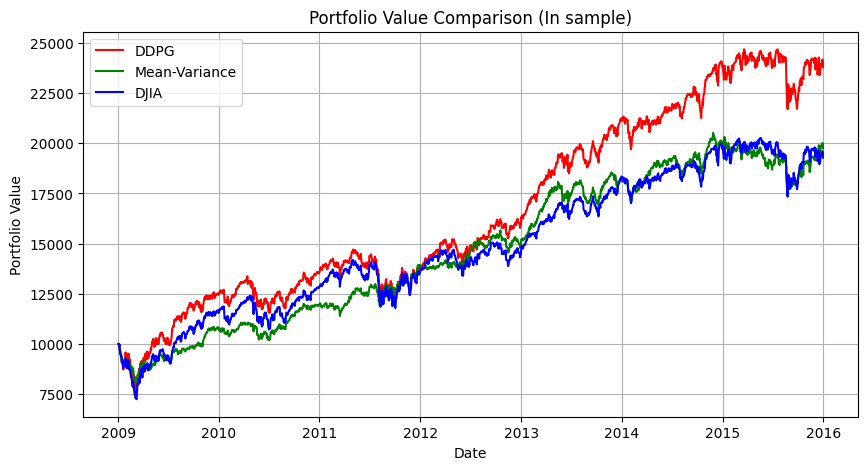

In [13]:
plt.figure(figsize=(10,5))

# DDPG
plt.plot(train_df['Date'], portfolio_values_train, label="DDPG", color = 'red')

# Mean-Variance
plt.plot(train_returns.index, min_var_port_val_train, label="Mean-Variance", color='green')

# DJIA
plt.plot(djia_train['Date'], djia_train['Portfolio'], label="DJIA", color = 'blue')

plt.title("Portfolio Value Comparison (In sample)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

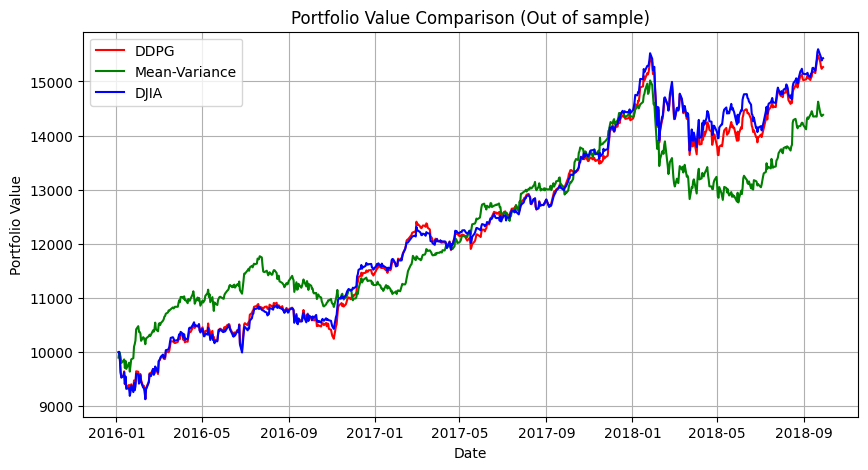

In [14]:
plt.figure(figsize=(10,5))

# DDPG
plt.plot(test_df['Date'], test_portfolio, label="DDPG", color ='red')


# Mean-Variance
plt.plot(test_returns.index, min_var_port_val_test, label="Mean-Variance", color='green')


# DJIA
plt.plot(djia_test['Date'], djia_test['Portfolio'], label="DJIA",color='blue')

plt.title("Portfolio Value Comparison (Out of sample)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

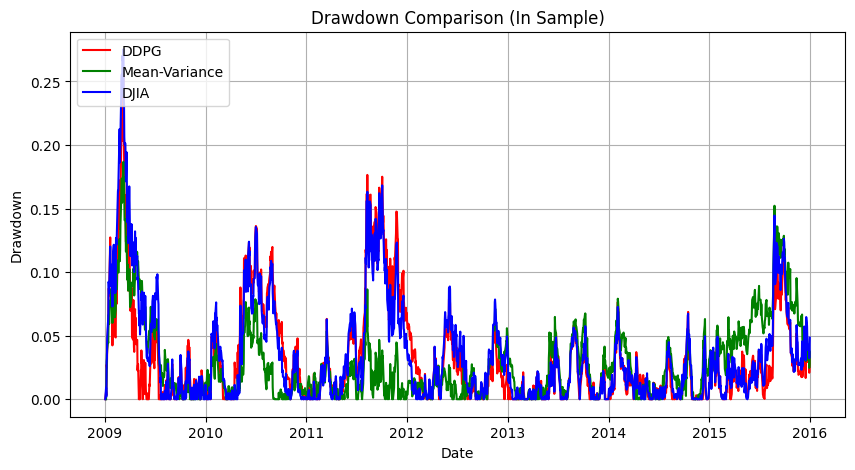

In [15]:
# drawdown comparison for training
plt.figure(figsize=(10,5))
# DDPG drawdown
plt.plot(train_df['Date'], drawdowns(portfolio_values_train), label="DDPG", color = 'red')
# Mean-Variance drawdown
plt.plot(train_returns.index, drawdowns(min_var_port_val_train), label="Mean-Variance", color='green')
# DJIA drawdown
plt.plot(djia_train['Date'], drawdowns(djia_port_train), label="DJIA", color='blue')

plt.title("Drawdown Comparison (In Sample)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

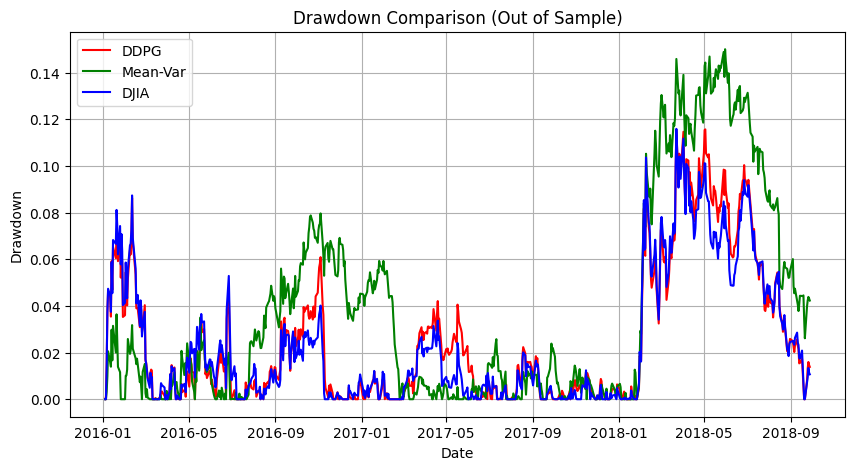

In [16]:
# drawdown comparsion for testing
plt.figure(figsize=(10,5))
# DDPG drawdown
plt.plot(test_df['Date'], drawdowns(test_portfolio), label="DDPG", color = 'red')
# Mean-Variance drawdown
plt.plot(test_returns.index, drawdowns(min_var_port_val_test), label="Mean-Var", color='green')
# DJIA drawdown
plt.plot(djia_test['Date'], drawdowns(djia_port_test), label="DJIA", color='blue')


plt.title("Drawdown Comparison (Out of Sample)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [17]:
#Train table
table_train = pd.DataFrame({
    "DDPG (ours)": list(ddpg_stats_train),
    "Mean-Variance": list(minvar_stats_train),
    "DJIA": list(djia_stats_train)
}, index=[
    "Initial Portfolio Value",
    "Final Portfolio Value",
    "Annualized Return",
    "Annualized Std.Error",
    "Sharpe Ratio",
    "Max Drawdown",
    "AVG Drawdown"
])

print(table_train)

                          DDPG (ours)  Mean-Variance          DJIA
Initial Portfolio Value  10000.000000   10000.000000  10000.000000
Final Portfolio Value    23788.326172   19750.778189  19286.802832
Annualized Return            0.138363       0.106599      0.107431
Annualized Std.Error         0.169232       0.119541      0.163780
Sharpe Ratio                 0.728958       0.766254      0.564361
Max Drawdown                 0.256824       0.186764      0.275343
AVG Drawdown                 0.032241       0.028970      0.034735


In [18]:
#Test table
table_test = pd.DataFrame({
    "DDPG (ours)": list(ddpg_stats_test),
    "Mean-Variance": list(minvar_stats_test),
    "DJIA": list(djia_stats_test)
}, index=[
    "Initial Portfolio Value",
    "Final Portfolio Value",
    "Annualized Return",
    "Annualized Std.Error",
    "Sharpe Ratio",
    "Max Drawdown",
    "AVG Drawdown"
])

print(table_test)

                          DDPG (ours)  Mean-Variance          DJIA
Initial Portfolio Value  10000.000000   10000.000000  10000.000000
Final Portfolio Value    15266.159180   14382.953526  15428.540417
Annualized Return            0.161387       0.141957      0.165302
Annualized Std.Error         0.116655       0.104968      0.117072
Sharpe Ratio                 1.254875       1.209488      1.283835
Max Drawdown                 0.115618       0.149981      0.115849
AVG Drawdown                 0.025271       0.038328      0.023482
